In [225]:
# Imports and Drive connection
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore') #Not showing any warning messages
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [226]:
# File paths — update to match your Drive folder
raw_p       = '/content/drive/MyDrive/Research 2025-26/SP26 Research Fellowship/Gabriel/data/raw'
processed_p = '/content/drive/MyDrive/Research 2025-26/SP26 Research Fellowship/Gabriel/data/processed'
os.makedirs(processed_p, exist_ok=True)
print('Raw folder contents:', os.listdir(raw_p))

Raw folder contents: ['annual_conc_by_monitor_2020.csv', 'annual_conc_by_monitor_2021.csv', 'annual_conc_by_monitor_2022.csv', 'annual_conc_by_monitor_2023.csv', 'annual_conc_by_monitor_2024.csv', 'annual_conc_by_monitor_2020.gsheet', 'uszips.csv', 'Vehicle_Population_Last_updated_04-30-2025_ada.xlsx', 'calenviroscreen50csv_d_12226.csv', 'ZIP_TRACT_122020.xlsx', 'acs037.json', 'acs059.json', 'acs065.json', 'acs071.json', 'acs073.json', 'acs083.json', 'acs111.json', 'calenviroscreen40resultsdatadictionary_F_2021.csv']


---

In [191]:
# Load and combine all EPA air quality CSVs
# Source: EPA AirData AQS — https://aqs.epa.gov/aqsweb/airdata/download_files.html
# Files: annual_conc_by_monitor_20XX.csv for years 2020-2024

csv_files = [f for f in os.listdir(raw_p)
             if f.endswith('.csv') and f.startswith('annual_conc')]
print(f'Found {len(csv_files)} AQ files')

dfs = []
for f in csv_files:
    temp = pd.read_csv(os.path.join(raw_p, f), low_memory=False)
    dfs.append(temp)
    print(f'  Loaded {f}: {len(temp):,} rows')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows: {len(df):,}')
print(f'Years: {sorted(df["Year"].dropna().unique().tolist())}')

Found 5 AQ files
  Loaded annual_conc_by_monitor_2020.csv: 77,407 rows
  Loaded annual_conc_by_monitor_2021.csv: 106,455 rows
  Loaded annual_conc_by_monitor_2022.csv: 75,029 rows
  Loaded annual_conc_by_monitor_2023.csv: 82,378 rows
  Loaded annual_conc_by_monitor_2024.csv: 67,923 rows

Total rows: 409,192
Years: [2020, 2021, 2022, 2023, 2024]


In [192]:
# Split into 2020 (baseline controls) and 2021-2024 (study years)
# 2020 = pre-period values for income and CalEnviroScreen (avoids endogeneity)
# 2021-2024 = what we actually analyze

df_2020 = df[df['Year'] == 2020]
df_obs  = df[df['Year'].isin([2021, 2022, 2023, 2024])]
print(f'2020 baseline rows: {len(df_2020):,}')
print(f'2021-2024 observation rows: {len(df_obs):,}')

2020 baseline rows: 77,407
2021-2024 observation rows: 331,785


In [193]:
# Filter to all Southern California counties
# 37=LA, 59=Orange, 65=Riverside, 71=San Bernardino, 73=San Diego, 83=Santa Barbara, 111=Ventura

SOCAL_COUNTIES = {37, 59, 65, 71, 73, 83, 111}

df_socal = df_obs[
    (df_obs['State Code'] == 6) &
    (df_obs['County Code'].isin(SOCAL_COUNTIES))
]
cities = df_socal['City Name'].dropna().unique()
print(f'SoCal rows: {len(df_socal):,}')
print(f'Cities found: {sorted(cities)}')

SoCal rows: 16,575
Cities found: ['Alpine', 'Anaheim', 'Azusa', 'Banning', 'Barstow', 'Big Bear City', 'Blythe', 'Boulevard', 'Camp Pendleton South', 'Campo', 'Capitan', 'Carlsbad', 'Carpinteria', 'Chula Vista', 'Commerce', 'Compton', 'Crestline', 'El Cajon', 'Fontana', 'Glendora', 'Goleta', 'Hesperia', 'Indio', 'Industry (corporate name for City of Industry)', 'Isla Vista', 'Joshua Tree National Monument', 'La Habra', 'Lake Elsinore', 'Lancaster', 'Lompoc', 'Long Beach', 'Los Angeles', 'Los Padres National Forest', 'Lucerne Valley', 'Mecca', 'Mira Loma', 'Mission Viejo', 'Norco', 'Ojai', 'Ontario', 'Orcutt', 'Otay Mesa', 'Pala', 'Palm Springs', 'Pasadena', 'Perris', 'Pico Rivera', 'Piru', 'Pomona', 'Redlands', 'Reseda', 'Rubidoux', 'San Bernardino', 'San Diego', 'Santa Barbara', 'Santa Clarita', 'Santa Fe Springs', 'Santa Maria', 'Searles Valley', 'Signal Hill', 'Simi Valley', 'Thousand Oaks', 'Torres-Martinez I.R.', 'Upland', 'Vernon', 'Victorville', 'West Los Angeles']


In [194]:
# Extract PM2.5 annual mean per city per year
# Parameter 88101 = PM2.5, Duration '24-HR BLK AVG' = 24-hour block average
# Obs% >= 75 = EPA's minimum completeness threshold for a valid annual mean
# groupby + mean handles multiple monitors (POCs) at the same location

pm25 = df_socal[
    (df_socal['Parameter Code'] == 88101) &
    (df_socal['Pollutant Standard'].str.contains('Annual', na=False)) &
    (df_socal['Metric Used'] == 'Quarterly Means of Daily Means') &
    (df_socal['Observation Percent'] >= 75)
].groupby(['City Name', 'Year'])['Arithmetic Mean'].mean().round(3).reset_index()
pm25.columns = ['City', 'Year', 'PM2.5']

print(f'PM2.5 city-year rows: {len(pm25)}')
print(sorted(pm25['City'].unique()))

PM2.5 city-year rows: 130
['Alpine', 'Anaheim', 'Azusa', 'Banning', 'Big Bear City', 'Camp Pendleton South', 'Campo', 'Carpinteria', 'Chula Vista', 'Compton', 'El Cajon', 'Fontana', 'Goleta', 'Indio', 'Lancaster', 'Lompoc', 'Long Beach', 'Los Angeles', 'Mira Loma', 'Mission Viejo', 'Ojai', 'Ontario', 'Orcutt', 'Otay Mesa', 'Pala', 'Palm Springs', 'Pasadena', 'Pico Rivera', 'Piru', 'Reseda', 'Rubidoux', 'San Bernardino', 'San Diego', 'Santa Barbara', 'Signal Hill', 'Simi Valley', 'Thousand Oaks', 'Victorville']


In [195]:
# Extract NO2 annual mean per city per year
# Parameter 42602 = NO2, Standard 'NO2 Annual 1971' = annual average standard
# (NOT the 1-hour peak standard — we want the full-year average)

no2 = df_socal[
    (df_socal['Parameter Code'] == 42602) &
    (df_socal['Pollutant Standard'] == 'NO2 Annual 1971') &
    (df_socal['Observation Percent'] >= 75)
].groupby(['City Name', 'Year'])['Arithmetic Mean'].mean().round(3).reset_index()
no2.columns = ['City', 'Year', 'NO2']
print(f'NO2 city-year rows: {len(no2)}')
print(no2.to_string(index=False))

NO2 city-year rows: 146
                      City  Year    NO2
                    Alpine  2021  4.351
                    Alpine  2022  3.643
                    Alpine  2023  3.168
                    Alpine  2024  3.662
                   Anaheim  2021 15.676
                   Anaheim  2022 15.325
                   Anaheim  2023 15.049
                   Anaheim  2024 15.188
                     Azusa  2021 14.762
                   Banning  2021  5.750
                   Banning  2022  8.308
                   Banning  2023  7.481
                   Banning  2024  8.481
                   Barstow  2021 14.555
                   Barstow  2022 14.484
                   Barstow  2023 13.317
                   Barstow  2024 14.098
      Camp Pendleton South  2021  5.457
      Camp Pendleton South  2022  5.452
      Camp Pendleton South  2023  4.953
      Camp Pendleton South  2024  4.949
                   Capitan  2021  0.688
                   Capitan  2022  0.756
                

In [196]:
# Keep only cities with BOTH pollutants in ALL 4 observation years
# Inner join = only rows where PM2.5 and NO2 both exist for the same city+year

both       = pd.merge(pm25, no2, on=['City', 'Year'], how='inner')
year_count = both.groupby('City')['Year'].count()
verified   = year_count[year_count == 4].index.tolist()

print('VERIFIED CITIES (both pollutants, all 4 years):')
for c in verified:
    print(f'  {c}')
print(f'\nTotal: {len(verified)}')

VERIFIED CITIES (both pollutants, all 4 years):
  Anaheim
  Banning
  Compton
  El Cajon
  Fontana
  Lancaster
  Lompoc
  Long Beach
  Los Angeles
  Mira Loma
  Ontario
  Palm Springs
  Pasadena
  Pico Rivera
  Reseda
  Rubidoux
  San Bernardino
  San Diego
  Simi Valley
  Victorville

Total: 20


In [197]:
# Save clean air quality dataset for verified cities

df_verified = both[both['City'].isin(verified)].sort_values(['City', 'Year'])
print(df_verified.to_string(index=False))

df_verified.to_csv(os.path.join(processed_p, 'AQ_verified_cities.csv'), index=False)
print('\nSaved AQ_verified_cities.csv')

          City  Year  PM2.5    NO2
       Anaheim  2021 11.362 15.676
       Anaheim  2022  9.284 15.325
       Anaheim  2023  9.739 15.049
       Anaheim  2024 10.757 15.188
       Banning  2021  7.744  5.750
       Banning  2022  6.861  8.308
       Banning  2023  5.965  7.481
       Banning  2024  6.866  8.481
       Compton  2021 13.434 14.028
       Compton  2022 12.103 14.395
       Compton  2023 11.116 12.654
       Compton  2024 12.333 12.644
      El Cajon  2021  9.738  8.306
      El Cajon  2022  8.974  8.253
      El Cajon  2023  9.203  6.860
      El Cajon  2024  8.967  6.839
       Fontana  2021 12.069 18.951
       Fontana  2022 10.916 17.701
       Fontana  2023 11.244 16.591
       Fontana  2024 13.599 19.416
     Lancaster  2021  8.108  8.259
     Lancaster  2022  7.518  8.102
     Lancaster  2023  3.385  3.350
     Lancaster  2024  4.756  3.335
        Lompoc  2021  5.800  1.521
        Lompoc  2022  5.604  2.746
        Lompoc  2023  4.582  1.052
        Lompoc  2024

---

In [198]:
# Load SimpleMaps ZIP database to map ZIPs to cities
# Source: SimpleMaps US ZIP Database — simplemaps.com
# Note: SimpleMaps may not list every city (CDPs / unincorporated areas)
#       We automatically detect which cities are missing and handle them below

zips_df = pd.read_csv(os.path.join(raw_p, 'uszips.csv'), dtype={'zip': str})
zips_df['zip']  = zips_df['zip'].str.zfill(5)
zips_df['city'] = zips_df['city'].str.strip()
print(f'SimpleMaps rows: {len(zips_df):,}')
print(zips_df[['zip','city','county_name','state_id']].head())

SimpleMaps rows: 33,782
     zip       city county_name state_id
0  00601   Adjuntas    Adjuntas       PR
1  00602     Aguada      Aguada       PR
2  00603  Aguadilla   Aguadilla       PR
3  00606    Maricao     Maricao       PR
4  00610     Anasco      Añasco       PR


In [199]:
# Check which verified cities are in SimpleMaps and which are missing
# CDPs (unincorporated communities) are often listed under a neighboring city name

sm_cities = set(zips_df[zips_df['state_id'] == 'CA']['city'].unique())
missing   = [c for c in verified if c not in sm_cities]
found     = [c for c in verified if c in sm_cities]

print('Found in SimpleMaps:', found)
print('NOT found in SimpleMaps (need manual ZIPs):', missing)

# Search SimpleMaps for partial name matches to help identify correct ZIP
for city in missing:
    partial = zips_df[zips_df['city'].str.contains(city, case=False, na=False)]
    if len(partial) > 0:
        print(f"\nPartial matches for '{city}':")
        print(partial[['zip','city','county_name']].to_string(index=False))
    else:
        print(f"\nNo matches for '{city}' — look up ZIP on usps.com")

Found in SimpleMaps: ['Anaheim', 'Banning', 'Compton', 'El Cajon', 'Fontana', 'Lancaster', 'Lompoc', 'Long Beach', 'Los Angeles', 'Mira Loma', 'Ontario', 'Palm Springs', 'Pasadena', 'Pico Rivera', 'Reseda', 'San Bernardino', 'San Diego', 'Simi Valley', 'Victorville']
NOT found in SimpleMaps (need manual ZIPs): ['Rubidoux']

No matches for 'Rubidoux' — look up ZIP on usps.com


In [200]:
# Build the full ZIP lookup
# After running the cell above, fill in manual_zips for any missing cities
# Source for manual ZIPs: USPS ZIP lookup tool (usps.com), accessed March 2026

# --- MAKE QUESTION ABOUT THIS ---
manual_zips = {
  'Rubidoux': ['92509']
}
# -------------------------------------------

# Get ZIPs from SimpleMaps for cities that are in it
sm_lookup = zips_df[
    (zips_df['state_id'] == 'CA') &
    (zips_df['city'].isin(verified))
][['zip', 'city', 'county_name']].drop_duplicates().copy()

# Add manual rows
manual_rows = pd.DataFrame([
    {'zip': z, 'city': city, 'county_name': 'Manual'}
    for city, zips_list in manual_zips.items()
    for z in zips_list
])

if len(manual_rows) > 0:
    city_zip_lookup = pd.concat([sm_lookup, manual_rows], ignore_index=True)
else:
    city_zip_lookup = sm_lookup.copy()

city_zip_lookup['zip'] = city_zip_lookup['zip'].astype(str).str.zfill(5)

# Check for still-missing cities
still_missing = [c for c in verified if c not in city_zip_lookup['city'].values]
if still_missing:
    print(f'STILL MISSING — add to manual_zips above: {still_missing}')
else:
    print('All verified cities have ZIP codes!')

print(city_zip_lookup.to_string(index=False))

city_zip_lookup.to_csv(os.path.join(processed_p, 'city_zip_lookup.csv'), index=False)
print('Saved city_zip_lookup.csv')

All verified cities have ZIP codes!
  zip           city    county_name
90001    Los Angeles    Los Angeles
90002    Los Angeles    Los Angeles
90003    Los Angeles    Los Angeles
90004    Los Angeles    Los Angeles
90005    Los Angeles    Los Angeles
90006    Los Angeles    Los Angeles
90007    Los Angeles    Los Angeles
90008    Los Angeles    Los Angeles
90011    Los Angeles    Los Angeles
90012    Los Angeles    Los Angeles
90013    Los Angeles    Los Angeles
90014    Los Angeles    Los Angeles
90015    Los Angeles    Los Angeles
90016    Los Angeles    Los Angeles
90017    Los Angeles    Los Angeles
90018    Los Angeles    Los Angeles
90019    Los Angeles    Los Angeles
90020    Los Angeles    Los Angeles
90021    Los Angeles    Los Angeles
90022    Los Angeles    Los Angeles
90023    Los Angeles    Los Angeles
90024    Los Angeles    Los Angeles
90025    Los Angeles    Los Angeles
90026    Los Angeles    Los Angeles
90027    Los Angeles    Los Angeles
90028    Los Angeles    Los 

---

In [201]:
# Load ZEV vehicle population data
# Source: California Energy Commission
# https://www.energy.ca.gov/files/zev-and-infrastructure-stats-data
# File: Vehicle_Population_Last_updated_04-30-2025_ada.xlsx

xl = pd.ExcelFile(os.path.join(raw_p, 'Vehicle_Population_Last_updated_04-30-2025_ada.xlsx'))
df_zev = pd.read_excel(xl, sheet_name='ZIP')
df_zev['ZIP'] = df_zev['ZIP'].astype(str).str.zfill(5)
print('Columns:', df_zev.columns.tolist())
print(df_zev.head())

Columns: ['Data Year', 'Dashboard Fuel Type Group', 'Fuel Type', 'ZIP', 'Number of Vehicles']
   Data Year Dashboard Fuel Type Group               Fuel Type    ZIP  \
0       2010    Battery Electric (BEV)  Battery Electric (BEV)  90010   
1       2010    Battery Electric (BEV)  Battery Electric (BEV)  90012   
2       2010    Battery Electric (BEV)  Battery Electric (BEV)  90020   
3       2010    Battery Electric (BEV)  Battery Electric (BEV)  90021   
4       2010    Battery Electric (BEV)  Battery Electric (BEV)  90024   

   Number of Vehicles  
0                   2  
1                   5  
2                   1  
3                   1  
4                   7  


In [202]:
# Filter to study years and your cities' ZIPs

df_zev = df_zev[df_zev['Data Year'].isin([2020, 2021, 2022, 2023, 2024])]

city_zips = city_zip_lookup[['zip','city']].rename(columns={'zip':'ZIP','city':'City'})
city_zips['ZIP'] = city_zips['ZIP'].astype(str).str.zfill(5)

df_zev_filtered = pd.merge(df_zev, city_zips, on='ZIP', how='inner')

# Strict filter — only verified cities (removes ZIP-boundary bleed into wrong cities)
df_zev_filtered = df_zev_filtered[df_zev_filtered['City'].isin(verified)]

print(f'Rows after filtering: {len(df_zev_filtered)}')
print(f'Cities: {sorted(df_zev_filtered["City"].unique())}')
print(f'Years:  {sorted(df_zev_filtered["Data Year"].unique())}')

Rows after filtering: 6399
Cities: ['Anaheim', 'Banning', 'Compton', 'El Cajon', 'Fontana', 'Lancaster', 'Lompoc', 'Long Beach', 'Los Angeles', 'Mira Loma', 'Ontario', 'Palm Springs', 'Pasadena', 'Pico Rivera', 'Reseda', 'Rubidoux', 'San Bernardino', 'San Diego', 'Simi Valley', 'Victorville']
Years:  [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [203]:
# Flag ZEV vs non-ZEV fuel types
# ZEV = Battery Electric (BEV) + Plug-in Hybrid (PHEV) + Fuel Cell (FCEV)

zev_types = ['Battery Electric (BEV)', 'Plug-in Hybrid (PHEV)', 'Fuel Cell (FCEV)']
df_zev_filtered['is_ZEV'] = df_zev_filtered['Fuel Type'].isin(zev_types)

print('Fuel type breakdown:')
print(df_zev_filtered.groupby(['Fuel Type','is_ZEV'])['Number of Vehicles'].sum().to_string())

Fuel type breakdown:
Fuel Type               is_ZEV
Battery Electric (BEV)  True        578220
Diesel                  False       245470
Flex Fuel               False       757372
Fuel Cell (FCEV)        True          8298
Gasoline                False     19240767
Gasoline Hybrid         False      1075159
Natural Gas             False         7902
Plug-in Hybrid (PHEV)   True        245111
Propane                 False          134


In [204]:
# Calculate ZEV adoption rate per city per year
# ZEV rate = ZEV vehicles / total vehicles (summed across all ZIPs in the city)

zev_counts = df_zev_filtered[df_zev_filtered['is_ZEV']].groupby(
    ['City','Data Year'])['Number of Vehicles'].sum().reset_index()
zev_counts.columns = ['City','Year','ZEV_count']

total_counts = df_zev_filtered.groupby(
    ['City','Data Year'])['Number of Vehicles'].sum().reset_index()
total_counts.columns = ['City','Year','Total_vehicles']

zev_rates = pd.merge(zev_counts, total_counts, on=['City','Year'])
zev_rates['ZEV_rate'] = (zev_rates['ZEV_count'] / zev_rates['Total_vehicles']).round(4)

print(zev_rates.to_string(index=False))
zev_rates.to_csv(os.path.join(processed_p, 'ZEV_rates.csv'), index=False)
print('\nSaved ZEV_rates.csv')

          City  Year  ZEV_count  Total_vehicles  ZEV_rate
       Anaheim  2020       4583          256521    0.0179
       Anaheim  2021       6250          264347    0.0236
       Anaheim  2022       8574          261155    0.0328
       Anaheim  2023      12039          262100    0.0459
       Anaheim  2024      15383          262546    0.0586
       Banning  2020        133           22912    0.0058
       Banning  2021        196           24340    0.0081
       Banning  2022        302           24104    0.0125
       Banning  2023        476           24589    0.0194
       Banning  2024        702           25278    0.0278
       Compton  2020        345           86882    0.0040
       Compton  2021        474           91368    0.0052
       Compton  2022        644           88131    0.0073
       Compton  2023        992           86742    0.0114
       Compton  2024       1484           85582    0.0173
      El Cajon  2020       1170          124905    0.0094
      El Cajon

---

In [1]:
import json, pandas as pd, glob

frames = []
for filepath in glob.glob('/content/*.json'):
    with open(filepath) as f:
        data = json.load(f)
    frames.append(pd.DataFrame(data[1:], columns=data[0]))

df_acs_raw = pd.concat(frames, ignore_index=True)
df_acs_raw['B19013_001E'] = pd.to_numeric(df_acs_raw['B19013_001E'], errors='coerce')
df_acs_raw['B19013_001E'] = df_acs_raw['B19013_001E'].replace(-666666666, pd.NA)  # ← add this
df_acs_raw['GEOID'] = df_acs_raw['state'] + df_acs_raw['county'] + df_acs_raw['tract']
df_acs_raw = df_acs_raw.rename(columns={'B19013_001E': 'median_income'})

print(f'Total tracts: {len(df_acs_raw)}')
print(df_acs_raw[['GEOID', 'NAME', 'median_income']].head())

Total tracts: 5132
         GEOID                                               NAME  \
0  06037199700  Census Tract 1997, Los Angeles County, California   
1  06037199801  Census Tract 1998.01, Los Angeles County, Cali...   
2  06037199802  Census Tract 1998.02, Los Angeles County, Cali...   
3  06037199900  Census Tract 1999, Los Angeles County, California   
4  06037201110  Census Tract 2011.10, Los Angeles County, Cali...   

  median_income  
0         38892  
1         41027  
2         42500  
3         37232  
4         65000  


In [2]:
# Aggregate income to city level via HUD ZIP-to-Tract crosswalk
# Source: HUD USPS Crosswalk Files (Q4 2020)
# https://www.huduser.gov/portal/datasets/usps_crosswalk.html
# File: ZIP_TRACT_122020.xlsx

df_hud = pd.read_excel(os.path.join(raw_p, 'ZIP_TRACT_122020.xlsx'),
                       dtype={'ZIP': str, 'TRACT': str})
df_hud['ZIP']   = df_hud['ZIP'].str.zfill(5)
df_hud['TRACT'] = df_hud['TRACT'].str.zfill(11)

study_zips = city_zip_lookup['zip'].astype(str).str.zfill(5).unique()
df_hud_s   = df_hud[df_hud['ZIP'].isin(study_zips)].copy()

# Join ACS income onto tracts
df_hud_s = df_hud_s.merge(df_acs_raw[['GEOID','median_income']],
                           left_on='TRACT', right_on='GEOID', how='left')

# Weighted mean income per ZIP (weight = share of addresses in that tract)
def wmean(g):
    v = g.dropna(subset=['median_income'])
    return (v['median_income'] * v['TOT_RATIO']).sum() / v['TOT_RATIO'].sum() if len(v) else None

zip_income = df_hud_s.groupby('ZIP').apply(wmean, include_groups=False).reset_index()
zip_income.columns = ['zip', 'income_weighted']

zip_income = zip_income.merge(
    city_zip_lookup[['zip','city']].assign(zip=lambda x: x['zip'].str.zfill(5)),
    on='zip', how='left')

city_income = zip_income.groupby('city')['income_weighted'].mean().round(0).reset_index()
city_income.columns = ['City','median_income']

print('Median household income by city (2020):')
print(city_income.sort_values('median_income').to_string(index=False))

NameError: name 'os' is not defined

---

In [207]:
# Load CalEnviroScreen 4.0 scores (Oct 2021, close to 2020 baseline)
# Source: OEHHA — https://oehha.ca.gov/calenviroscreen/report/calenviroscreen-40

df_ces_raw = pd.read_csv(os.path.join(raw_p, 'calenviroscreen40resultsdatadictionary_F_2021.csv'),
                         dtype={'ZIP': str})

df_ces_raw['California County'] = df_ces_raw['California County'].str.strip()
df_ces_raw['tract'] = df_ces_raw['Census Tract'].astype(str).str.zfill(11)
df_ces_raw['ZIP']   = df_ces_raw['ZIP'].astype(str).str.strip().str.zfill(5)

# Drop rows where ZIP is all zeros or null (bad data)
df_ces_raw = df_ces_raw[df_ces_raw['ZIP'].notna() & (df_ces_raw['ZIP'] != '00000')]

SOCAL_COUNTIES_NAMES = ['Los Angeles','Orange','Riverside','San Bernardino',
                        'San Diego','Santa Barbara','Ventura']
df_ces = df_ces_raw[df_ces_raw['California County'].isin(SOCAL_COUNTIES_NAMES)].copy()
df_ces = df_ces.rename(columns={
    'California County': 'county',
    'CES 4.0 Score':     'CIscore',
    'CES 4.0 Percentile':'CIscoreP',
})

# Diagnostic — check if your city ZIPs are present
test_zips = ['92801','92220','92509','91752','93063','93065']
print('ZIP presence check:')
print(df_ces[df_ces['ZIP'].isin(test_zips)].groupby('ZIP')['CIscore'].count())

print(f'\nSoCal CES tracts: {len(df_ces)}')
print(df_ces[['tract','ZIP','county','CIscore','CIscoreP']].head())

ZIP presence check:
ZIP
91752     7
92220     7
92509    15
92801    10
93063    11
93065    15
Name: CIscore, dtype: int64

SoCal CES tracts: 4636
          tract    ZIP       county    CIscore   CIscoreP
2   06037204920  90023  Los Angeles  82.393909  99.974786
5   06037542402  90221  Los Angeles  80.708813  99.936964
7   06037543202  90220  Los Angeles  79.290119  99.911750
10  06037203300  90033  Los Angeles  77.349097  99.873928
11  06037291220  90247  Los Angeles  77.253279  99.861321


In [227]:
# Aggregate CES score to city level
# Match by city name directly from the CES county field — more reliable than ZIP join

# Build a city->county mapping from the EPA data
city_county_map = (df_socal[df_socal['City Name'].isin(verified)]
                   [['City Name','County Name']]
                   .drop_duplicates()
                   .rename(columns={'City Name':'City','County Name':'ces_county'}))

# CES uses slightly different county names — standardize
ces_county_map = {
    'Los Angeles': 'Los Angeles', 'Orange': 'Orange',
    'Riverside': 'Riverside', 'San Bernardino': 'San Bernardino',
    'San Diego': 'San Diego', 'Santa Barbara': 'Santa Barbara',
    'Ventura': 'Ventura'
}

# For each verified city, take the mean CES score across all tracts in that county
# then refine by ZIP overlap where possible
city_ces_rows = []
for _, row in city_county_map.iterrows():
    city = row['City']

    # First try: match by ZIP
    city_zips_set = city_zip_lookup[city_zip_lookup['city'] == city]['zip'].astype(str).str.zfill(5).tolist()
    ces_zip_match = df_ces[df_ces['ZIP'].isin(city_zips_set)]

    if len(ces_zip_match) >= 3:
        score = ces_zip_match['CIscore'].mean()
        pctl  = ces_zip_match['CIscoreP'].mean()
        method = 'ZIP'
    else:
        # Fallback: use county average
        county = row['ces_county']
        ces_county_match = df_ces[df_ces['county'] == county]
        score = ces_county_match['CIscore'].mean()
        pctl  = ces_county_match['CIscoreP'].mean()
        method = 'county avg'

    city_ces_rows.append({'City': city, 'CES_score': round(score,2),
                          'CES_percentile': round(pctl,2), 'method': method})
    print(f"  {city}: CES={score:.1f} ({method})")

city_ces = pd.DataFrame(city_ces_rows)
city_ces['CES_quartile'] = pd.qcut(city_ces['CES_score'], q=4,
                                    labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
print('\nCalEnviroScreen scores by city:')
print(city_ces.sort_values('CES_score').to_string(index=False))

  Los Angeles: CES=43.5 (ZIP)
  Reseda: CES=46.1 (ZIP)
  Compton: CES=61.1 (ZIP)
  Pico Rivera: CES=47.1 (ZIP)
  Pasadena: CES=22.9 (ZIP)
  Long Beach: CES=39.5 (ZIP)
  Lancaster: CES=31.7 (ZIP)
  Anaheim: CES=36.0 (ZIP)
  Banning: CES=38.2 (ZIP)
  Palm Springs: CES=15.4 (ZIP)
  Rubidoux: CES=44.6 (ZIP)
  Mira Loma: CES=35.1 (ZIP)
  Ontario: CES=44.7 (ZIP)
  Victorville: CES=31.8 (ZIP)
  Fontana: CES=37.9 (ZIP)
  San Bernardino: CES=45.1 (ZIP)
  San Diego: CES=21.1 (ZIP)
  El Cajon: CES=24.7 (ZIP)
  Lompoc: CES=23.0 (ZIP)
  Simi Valley: CES=18.7 (ZIP)

CalEnviroScreen scores by city:
          City  CES_score  CES_percentile method CES_quartile
  Palm Springs      15.44           26.36    ZIP     Q1 (Low)
   Simi Valley      18.70           34.18    ZIP     Q1 (Low)
     San Diego      21.08           37.06    ZIP     Q1 (Low)
      Pasadena      22.90           42.91    ZIP     Q1 (Low)
        Lompoc      23.03           43.56    ZIP     Q1 (Low)
      El Cajon      24.72           4

---

In [228]:
# Merge everything into one master panel — one row per city per year (2021-2024)
# Time-invariant variables (income, CES, coastal) are the same value every year per city

# 1. Calculate the lag on zev_rates BEFORE merging (so 2020 data is used!)
zev_rates = zev_rates.sort_values(['City', 'Year'])
zev_rates['ZEV_rate_lag'] = zev_rates.groupby('City')['ZEV_rate'].shift(1)

# Null out 2021 lag — keeps the observation period clean
# 2020 ZEV data exists but 2020 is our pre-period baseline, not an observation year
# Mixing it into the lag would make the persistence test span the COVID disruption
zev_rates.loc[zev_rates['Year'] == 2021, 'ZEV_rate_lag'] = np.nan

# 2. Setup the panel
panel = df_verified.copy()
panel = panel.rename(columns={'PM2.5': 'PM25'})   # rename for regression formula syntax

# 3. Merge everything
# Notice we merge ZEV_rate and ZEV_rate_lag together here in one step
panel = panel.merge(zev_rates[['City','Year','ZEV_rate','ZEV_rate_lag','Total_vehicles']], on=['City','Year'], how='left')
panel = panel.merge(city_income, on='City', how='left')
panel = panel.merge(city_ces[['City','CES_score','CES_percentile','CES_quartile']], on='City', how='left')

# Scale income to $10k units so the coefficient is readable
panel['income_10k'] = panel['median_income'] / 10_000

# Year dummy variables for fixed effects (absorb year-specific trends)
panel = pd.get_dummies(panel, columns=['Year'], prefix='Year', drop_first=True)
year_dummies = [c for c in panel.columns if c.startswith('Year_')]

print(f'Panel shape: {panel.shape}')
print(f'Missing values:\n{panel.isnull().sum()[panel.isnull().sum()>0]}')
print('\nFull panel:')
print(panel[['City','PM25','NO2','ZEV_rate','median_income','CES_score','ZEV_rate_lag']].to_string(index=False))

Panel shape: (80, 14)
Missing values:
ZEV_rate_lag    20
dtype: int64

Full panel:
          City   PM25    NO2  ZEV_rate  median_income  CES_score  ZEV_rate_lag
       Anaheim 11.362 15.676    0.0236        87474.0      35.99           NaN
       Anaheim  9.284 15.325    0.0328        87474.0      35.99        0.0236
       Anaheim  9.739 15.049    0.0459        87474.0      35.99        0.0328
       Anaheim 10.757 15.188    0.0586        87474.0      35.99        0.0459
       Banning  7.744  5.750    0.0081        44317.0      38.20           NaN
       Banning  6.861  8.308    0.0125        44317.0      38.20        0.0081
       Banning  5.965  7.481    0.0194        44317.0      38.20        0.0125
       Banning  6.866  8.481    0.0278        44317.0      38.20        0.0194
       Compton 13.434 14.028    0.0052        59170.0      61.11           NaN
       Compton 12.103 14.395    0.0073        59170.0      61.11        0.0052
       Compton 11.116 12.654    0.0114        59

In [229]:
# Save master panel
panel.to_csv(os.path.join(processed_p, 'master_panel.csv'), index=False)
print('Saved master_panel.csv')

Saved master_panel.csv


---

In [231]:
# Regression setup — run each model for both PM2.5 and NO2
OUTCOMES = ['PM25', 'NO2']
results_m1, results_m2, results_m3, results_m4 = {}, {}, {}, {}

In [232]:
# Check correlation between predictors
print("Correlation matrix:")
print(panel[['ZEV_rate', 'CES_score', 'income_10k']].corr().round(3))

# VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = panel.dropna(subset=['PM25', 'income_10k', 'ZEV_rate', 'CES_score'])
X = data[['income_10k', 'ZEV_rate', 'CES_score']].assign(const=1)
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("\nVIF:")
print(vif.to_string(index=False))

Correlation matrix:
            ZEV_rate  CES_score  income_10k
ZEV_rate       1.000     -0.476       0.483
CES_score     -0.476      1.000      -0.446
income_10k     0.483     -0.446       1.000

VIF:
  variable       VIF
income_10k  1.415126
  ZEV_rate  1.466393
 CES_score  1.403937
     const 63.059807


In [233]:
# Residualize ZEV and CES against income
# This removes the shared wealth gradient from both variables
# so the model can identify their independent contributions
panel['log_total_vehicles'] = np.log(panel['Total_vehicles'])

zev_resid_model = smf.ols('ZEV_rate ~ income_10k + log_total_vehicles', data=panel).fit()
panel['ZEV_rate_resid'] = zev_resid_model.resid

ces_resid_model = smf.ols('CES_score ~ income_10k', data=panel).fit()
panel['CES_score_resid'] = ces_resid_model.resid

# Also do the same for the lagged ZEV rate
zev_lag_resid_model = smf.ols('ZEV_rate_lag ~ income_10k + log_total_vehicles',
                               data=panel.dropna(subset=['ZEV_rate_lag'])).fit()
panel.loc[panel['ZEV_rate_lag'].notna(), 'ZEV_rate_lag_resid'] = zev_lag_resid_model.resid

# Verify the collinearity is gone
print("Correlation after residualizing:")
print(panel[['ZEV_rate_resid', 'CES_score_resid', 'income_10k']].corr().round(3))
# ZEV_rate_resid and CES_score_resid should now be near zero

Correlation after residualizing:
                 ZEV_rate_resid  CES_score_resid  income_10k
ZEV_rate_resid            1.000           -0.362        -0.0
CES_score_resid          -0.362            1.000         0.0
income_10k               -0.000            0.000         1.0


In [234]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

data_vif = panel.dropna(subset=['PM25', 'income_10k', 'ZEV_rate_resid', 'CES_score_resid'])
X_vif = data_vif[['income_10k', 'ZEV_rate_resid', 'CES_score_resid']].assign(const=1)
vif_after = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("\nVIF after residualization:")
print(vif_after.to_string(index=False))
# All values should be close to 1.0 — confirms collinearity is resolved


VIF after residualization:
       variable       VIF
     income_10k  1.000000
 ZEV_rate_resid  1.150656
CES_score_resid  1.150656
          const 26.326323


In [235]:
print(panel.groupby('City')[['ZEV_rate', 'PM25', 'NO2', 'CES_score', 'income_10k']].mean().round(3).sort_values('ZEV_rate'))

                ZEV_rate    PM25     NO2  CES_score  income_10k
City                                                           
Compton            0.010  12.246  13.430      61.11       5.917
San Bernardino     0.013  11.750  15.024      45.14       4.275
Pico Rivera        0.016  11.862  16.413      47.13       6.651
Lompoc             0.016   5.059   1.579      23.03       6.990
Rubidoux           0.017  11.709  12.742      44.56       7.974
Banning            0.017   6.859   7.505      38.20       4.432
Victorville        0.017   9.020  11.651      31.80       6.019
Lancaster          0.020   5.942   5.762      31.67       5.704
Fontana            0.026  11.957  18.165      37.89       7.225
El Cajon           0.026   9.220   7.564      24.72       7.605
Ontario            0.031  13.733  27.105      44.69       6.701
Reseda             0.034   9.455   9.934      46.07       6.938
Mira Loma          0.037  13.274  11.159      35.14       7.326
Long Beach         0.037  12.258  23.022

In [236]:
# MODEL 1: Baseline — income + coastal control only
#
# Equation:  AQ(i,t) = α + β1·Income(i) + γ(t) + ε(i,t)
#
# Purpose: How much air quality variation between cities is explained by wealth?
# β1 (income)     — expected negative: richer cities tend to have cleaner air
# γ(t)            — year fixed effects: absorb shared annual trends

print('='*60)
print('MODEL 1')
print('Equation: AQ = α + β1·Income + γ(year) + ε')
print('='*60)

for outcome in OUTCOMES:
    formula = f'{outcome} ~ income_10k + {" + ".join(year_dummies)}'
    data    = panel.dropna(subset=[outcome, 'income_10k'])
    model   = smf.ols(formula, data=data).fit(
                  cov_type='cluster', cov_kwds={'groups': data['City']})
    results_m1[outcome] = model

    print(f'\n{outcome}  |  N={int(model.nobs)}  R²={model.rsquared:.3f}  Adj R²={model.rsquared_adj:.3f}')
    for var in ['income_10k']:
        p = model.pvalues[var]
        s = '***' if p<.01 else '**' if p<.05 else '*' if p<.10 else ''
        print(f'  {var:<15}  β={model.params[var]:>8.4f}  SE={model.bse[var]:.4f}  p={p:.3f} {s}')

MODEL 1
Equation: AQ = α + β1·Income + γ(year) + ε

PM25  |  N=80  R²=0.061  Adj R²=0.011
  income_10k       β=  0.0455  SE=0.3908  p=0.907 

NO2  |  N=80  R²=0.014  Adj R²=-0.039
  income_10k       β= -0.0342  SE=0.7196  p=0.962 


In [237]:
# MODEL 2: Add ZEV adoption + CalEnviroScreen
#
# Equation:  AQ(i,t) = α + β1·Income(i) + β2·ZEV(i,t) + β3·CES(i)
#                         + γ(t) + ε(i,t)
#
# Purpose: Does ZEV adoption explain air quality beyond income alone?
# β2 (ZEV)  — expected negative: more EVs -> less pollution
# β3 (CES)  — controls for pre-existing environmental burden
# If Adj R² rises meaningfully vs Model 1, ZEV and CES are doing real work

print('='*60)
print('MODEL 2')
print('Equation: AQ = α + β1·Income + β2·ZEV + β3·CES + γ(year) + ε')
print('='*60)

for outcome in OUTCOMES:
    formula = formula = f'{outcome} ~ income_10k + log_total_vehicles + ZEV_rate_resid + CES_score_resid + {" + ".join(year_dummies)}'
    data    = panel.dropna(subset=[outcome,'income_10k','ZEV_rate','CES_score'])
    model   = smf.ols(formula, data=data).fit(
                  cov_type='cluster', cov_kwds={'groups': data['City']})
    results_m2[outcome] = model

    delta = model.rsquared_adj - results_m1[outcome].rsquared_adj
    print(f'\n{outcome}  |  N={int(model.nobs)}  R²={model.rsquared:.3f}  Adj R²={model.rsquared_adj:.3f}  ΔAdj R²={delta:+.3f}')
    for var in ['income_10k','ZEV_rate_resid','CES_score_resid']:
        p = model.pvalues[var]
        s = '***' if p<.01 else '**' if p<.05 else '*' if p<.10 else ''
        print(f'  {var:<15}  β={model.params[var]:>8.4f}  SE={model.bse[var]:.4f}  p={p:.3f} {s}')

MODEL 2
Equation: AQ = α + β1·Income + β2·ZEV + β3·CES + γ(year) + ε

PM25  |  N=80  R²=0.624  Adj R²=0.588  ΔAdj R²=+0.577
  income_10k       β= -0.0241  SE=0.2483  p=0.923 
  ZEV_rate_resid   β= 41.7314  SE=22.1029  p=0.059 *
  CES_score_resid  β=  0.2088  SE=0.0419  p=0.000 ***

NO2  |  N=80  R²=0.510  Adj R²=0.462  ΔAdj R²=+0.501
  income_10k       β= -0.3585  SE=0.4254  p=0.399 
  ZEV_rate_resid   β= 88.4768  SE=49.5241  p=0.074 *
  CES_score_resid  β=  0.3898  SE=0.1181  p=0.001 ***


In [238]:
print("ZEV_rate_lag non-null by year:")
# Reconstruct year from dummies to check
temp = panel.copy()
temp['Year'] = 2021
for col in year_dummies:
    yr = int(col.split('_')[1])
    temp.loc[temp[col] == 1, 'Year'] = yr

print(temp.groupby('Year')['ZEV_rate_lag'].apply(lambda x: x.notna().sum()))
print(f"\nRows with valid lag: {panel['ZEV_rate_lag'].notna().sum()}")
print(f"Rows WITHOUT valid lag: {panel['ZEV_rate_lag'].isna().sum()}")

ZEV_rate_lag non-null by year:
Year
2021     0
2022    20
2023    20
2024    20
Name: ZEV_rate_lag, dtype: int64

Rows with valid lag: 60
Rows WITHOUT valid lag: 20


In [239]:
# MODEL 3: Persistence test — lagged ZEV rate
#
# Equation:  AQ(i,t) = α + β1·Income(i) + β2·ZEV(i,t-1) + β3·CES(i)
#                         + γ(t) + ε(i,t)
#
# Key change: ZEV rate from the PRIOR year predicts air quality THIS year
# This is the core test of your research question — persistence
# If β2 is negative and significant -> ZEV adoption PRECEDES cleaner air
# Note: 2021 observations drop out (no 2020 ZEV lag in the dataset)

print('='*60)
print('MODEL 3 — Persistence test')
print('Equation: AQ = α + β1·Income + β2·ZEV(t-1) + β3·CES + γ(year) + ε')
print('='*60)

for outcome in OUTCOMES:
    formula = f'{outcome} ~ income_10k + log_total_vehicles + ZEV_rate_lag_resid + CES_score_resid + {" + ".join(year_dummies)}'
    data    = panel.dropna(subset=[outcome,'income_10k','ZEV_rate_lag','CES_score'])
    model   = smf.ols(formula, data=data).fit(
                  cov_type='cluster', cov_kwds={'groups': data['City']})
    results_m3[outcome] = model

    b = model.params['ZEV_rate_lag_resid']; p = model.pvalues['ZEV_rate_lag_resid']
    direction = 'negative (supports persistence)' if b < 0 else 'positive (unexpected)'
    print(f'\n{outcome}  |  N={int(model.nobs)} (2022-2024)  R²={model.rsquared:.3f}  Adj R²={model.rsquared_adj:.3f}')
    for var in ['income_10k','ZEV_rate_lag_resid','CES_score_resid']:
        p2 = model.pvalues[var]
        s2 = '***' if p2<.01 else '**' if p2<.05 else '*' if p2<.10 else ''
        print(f'  {var:<15}  β={model.params[var]:>8.4f}  SE={model.bse[var]:.4f}  p={p2:.3f} {s2}')
    print(f'  -> ZEV_rate_lag_resid is {direction} (p={p:.3f})')

MODEL 3 — Persistence test
Equation: AQ = α + β1·Income + β2·ZEV(t-1) + β3·CES + γ(year) + ε

PM25  |  N=60 (2022-2024)  R²=0.601  Adj R²=0.556
  income_10k       β= -0.0145  SE=0.2719  p=0.957 
  ZEV_rate_lag_resid  β= 50.6345  SE=26.4564  p=0.056 *
  CES_score_resid  β=  0.2036  SE=0.0428  p=0.000 ***
  -> ZEV_rate_lag_resid is positive (unexpected) (p=0.056)

NO2  |  N=60 (2022-2024)  R²=0.521  Adj R²=0.467
  income_10k       β= -0.3933  SE=0.4267  p=0.357 
  ZEV_rate_lag_resid  β=109.6096  SE=56.1157  p=0.051 *
  CES_score_resid  β=  0.3879  SE=0.1173  p=0.001 ***
  -> ZEV_rate_lag_resid is positive (unexpected) (p=0.051)


In [242]:
# MODEL 4: Equity test — ZEV × CalEnviroScreen interaction
print('='*60)
print('MODEL 4 — Equity test')
print('Equation: AQ = α + β1·Income + β2·ZEV(t-1) + β3·CES + β4·(ZEV×CES) + γ(year) + ε')
print('='*60)

# Year dummies already exist as columns
year_dummies = [c for c in panel.columns if c.startswith('Year_')]

for outcome in ['PM25', 'NO2']:                          # ← fixed: was OUTCOMES with 'AQ'
    data = panel.dropna(subset=[outcome, 'income_10k', 'ZEV_rate_lag', 'CES_score'])

    print(f'\n{outcome}: {len(data)} rows, {data["City"].nunique()} cities')

    if data['City'].nunique() < 2:
        print('  !! Too few cities after dropping NaNs — skipping')
        continue

    formula = (f'{outcome} ~ income_10k + log_total_vehicles + ZEV_rate_lag_resid + CES_score_resid + ZEV_rate_lag_resid:CES_score_resid + {" + ".join(year_dummies)}')

    # Fall back to HC3 if too few clusters for clustered SEs
    n_clusters = data['City'].nunique()
    if n_clusters < 10:
        print(f'  !! Only {n_clusters} clusters — using HC3 instead of clustered SEs')
        model = smf.ols(formula, data=data).fit(cov_type='HC3')
    else:
        model = smf.ols(formula, data=data).fit(
                    cov_type='cluster', cov_kwds={'groups': data['City']})

    results_m4[outcome] = model

    b4 = model.params['ZEV_rate_lag_resid:CES_score_resid']
    p4 = model.pvalues['ZEV_rate_lag_resid:CES_score_resid']
    s4 = '***' if p4<.01 else '**' if p4<.05 else '*' if p4<.10 else ''
    print(f'  N={int(model.nobs)}  R²={model.rsquared:.3f}  Adj R²={model.rsquared_adj:.3f}')
    for var in ['income_10k','ZEV_rate_lag_resid','CES_score_resid','ZEV_rate_lag_resid:CES_score_resid']:
        p2 = model.pvalues[var]
        s2 = '***' if p2<.01 else '**' if p2<.05 else '*' if p2<.10 else ''
        print(f'  {var:<30}  β={model.params[var]:>8.4f}  SE={model.bse[var]:.4f}  p={p2:.3f} {s2}')
    if p4 < 0.10:
        direction = 'SMALLER (equity gap)' if b4 > 0 else 'LARGER (equity gain)'
        print(f'  -> Interaction {s4}: ZEV benefit is {direction} in high-CES cities')
    else:
        print(f'  -> Interaction not significant (p={p4:.3f}) — no detectable equity difference')

MODEL 4 — Equity test
Equation: AQ = α + β1·Income + β2·ZEV(t-1) + β3·CES + β4·(ZEV×CES) + γ(year) + ε

PM25: 60 rows, 20 cities
  N=60  R²=0.603  Adj R²=0.550
  income_10k                      β= -0.0139  SE=0.2762  p=0.960 
  ZEV_rate_lag_resid              β= 57.7895  SE=37.8355  p=0.127 
  CES_score_resid                 β=  0.2060  SE=0.0451  p=0.000 ***
  ZEV_rate_lag_resid:CES_score_resid  β=  0.7631  SE=1.7725  p=0.667 
  -> Interaction not significant (p=0.667) — no detectable equity difference

NO2: 60 rows, 20 cities
  N=60  R²=0.522  Adj R²=0.457
  income_10k                      β= -0.3931  SE=0.4310  p=0.362 
  ZEV_rate_lag_resid              β=112.5094  SE=80.4422  p=0.162 
  CES_score_resid                 β=  0.3889  SE=0.1188  p=0.001 ***
  ZEV_rate_lag_resid:CES_score_resid  β=  0.3093  SE=4.0476  p=0.939 
  -> Interaction not significant (p=0.939) — no detectable equity difference


---

In [241]:
# Summary table — all four models side by side

def summary_table(outcome):
    models   = [results_m1, results_m2, results_m3, results_m4]
    labels   = ['M1: Baseline','M2: +ZEV+CES','M3: Lagged ZEV','M4: Interaction']
    key_vars = ['income_10k', 'ZEV_rate_resid', 'ZEV_rate_lag_resid',
            'CES_score_resid', 'ZEV_rate_lag_resid:CES_score_resid']
    rows = []
    for var in key_vars:
        row = {'Variable': var}
        for label, res in zip(labels, models):
            m = res.get(outcome)
            if m is None or var not in m.params:
                row[label] = '—'
            else:
                b = m.params[var]; p = m.pvalues[var]
                s = '***' if p<.01 else '**' if p<.05 else '*' if p<.10 else ''
                row[label] = f'{b:.4f}{s}'
        rows.append(row)
    for stat, fn in [('N', lambda m: int(m.nobs)),
                     ('R²', lambda m: round(m.rsquared,3)),
                     ('Adj R²', lambda m: round(m.rsquared_adj,3))]:
        row = {'Variable': stat}
        for label, res in zip(labels, models):
            m = res.get(outcome)
            row[label] = fn(m) if m else '—'
        rows.append(row)
    tbl = pd.DataFrame(rows).set_index('Variable')
    print(f'\n{"="*65}')
    print(f'  OUTCOME: {outcome}   (* p<.10  ** p<.05  *** p<.01)')
    print('='*65)
    print(tbl.to_string())

for outcome in OUTCOMES:
    summary_table(outcome)


  OUTCOME: PM25   (* p<.10  ** p<.05  *** p<.01)
                                   M1: Baseline M2: +ZEV+CES M3: Lagged ZEV M4: Interaction
Variable                                                                                   
income_10k                               0.0455      -0.0241        -0.0145               —
ZEV_rate_resid                                —     41.7314*              —               —
ZEV_rate_lag_resid                            —            —       50.6345*               —
CES_score_resid                               —    0.2088***      0.2036***               —
ZEV_rate_lag_resid:CES_score_resid            —            —              —               —
N                                            80           80             60               —
R²                                        0.061        0.624          0.601               —
Adj R²                                    0.011        0.588          0.556               —

  OUTCOME: NO2   (* p<.10  **

---

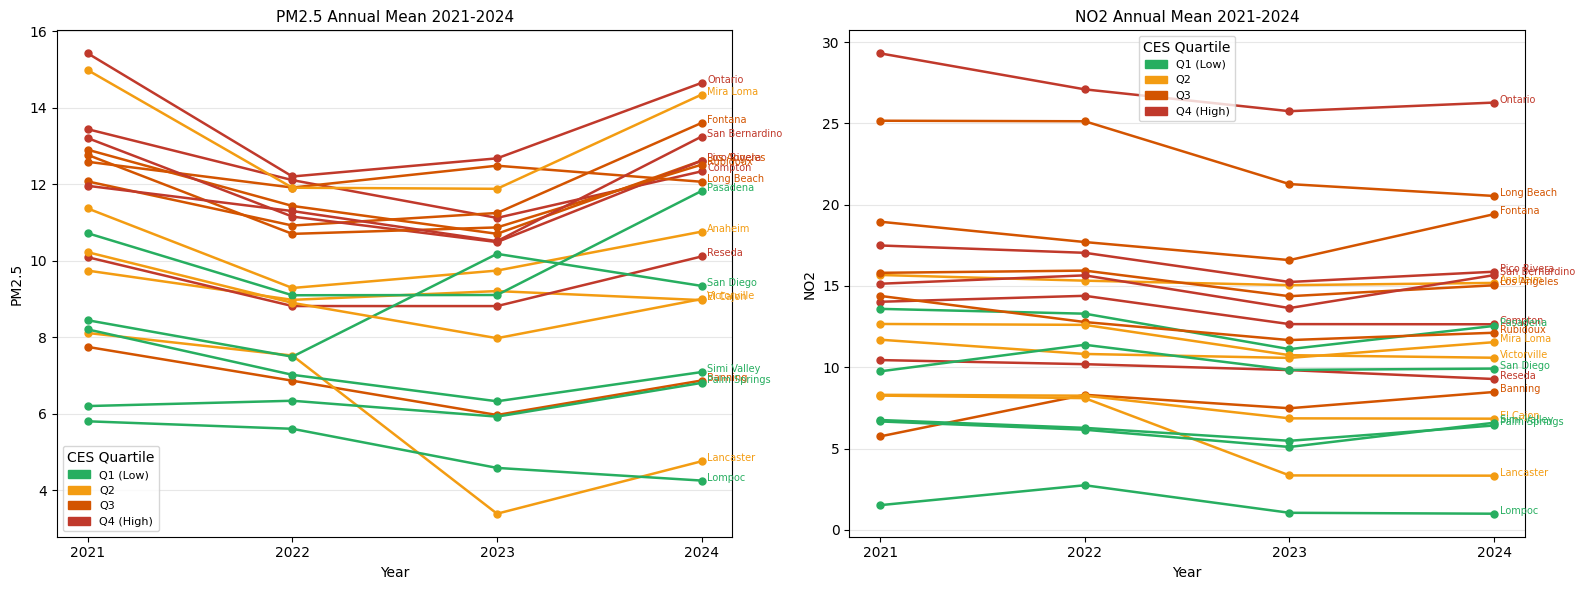

Saved trend_lines.png


In [222]:
# Plot: Pollution trend lines by city, colored by CES vulnerability quartile

plot_data = df_verified.copy()
plot_data = plot_data.merge(city_ces[['City','CES_quartile']], on='City', how='left')

quartile_colors = {'Q1 (Low)': '#27ae60', 'Q2': '#f39c12',
                   'Q3': '#d35400', 'Q4 (High)': '#c0392b'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, outcome in zip(axes, ['PM2.5','NO2']):
    for city, grp in plot_data.groupby('City'):
        grp   = grp.sort_values('Year')
        q     = str(grp['CES_quartile'].iloc[0])
        color = quartile_colors.get(q, '#999')
        ax.plot(grp['Year'], grp[outcome], marker='o', color=color,
                linewidth=1.8, markersize=5)
        last = grp.iloc[-1]
        ax.annotate(city, (last['Year'], last[outcome]),
                    textcoords='offset points', xytext=(4,0), fontsize=7, color=color)
    ax.set_title(f'{outcome} Annual Mean 2021-2024', fontsize=11)
    ax.set_ylabel(f'{outcome}', fontsize=10)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_xticks([2021, 2022, 2023, 2024])
    ax.grid(axis='y', alpha=0.3)
    handles = [mpatches.Patch(color=v, label=k) for k,v in quartile_colors.items()]
    ax.legend(handles=handles, fontsize=8, title='CES Quartile')

plt.tight_layout()
plt.savefig(os.path.join(processed_p, 'trend_lines.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved trend_lines.png')

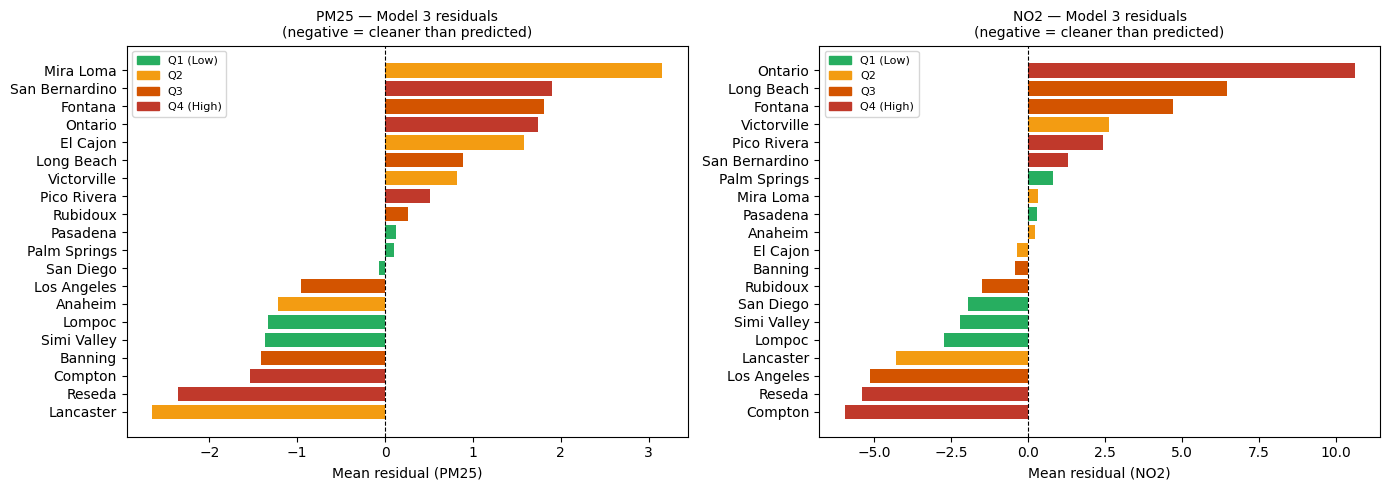

Saved residuals.png


In [223]:
# Plot: Model 3 residuals by city — who is over/under-performing?
# Negative residual = cleaner than the model predicts (over-performer)
# Positive residual = more polluted than the model predicts (under-performer)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, outcome in zip(axes, OUTCOMES):
    m    = results_m3[outcome]
    data = panel.dropna(subset=[outcome,'income_10k','ZEV_rate_lag','CES_score']).copy()
    data['residual'] = m.resid.values
    data['CES_q']    = data['City'].map(
        dict(zip(city_ces['City'], city_ces['CES_quartile'].astype(str))))

    city_resid = data.groupby(['City','CES_q'])['residual'].mean().reset_index()
    city_resid = city_resid.sort_values('residual')
    colors     = city_resid['CES_q'].map(quartile_colors).fillna('#aaa')

    ax.barh(city_resid['City'], city_resid['residual'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'Mean residual ({outcome})', fontsize=10)
    ax.set_title(f'{outcome} — Model 3 residuals\n(negative = cleaner than predicted)', fontsize=10)
    handles = [mpatches.Patch(color=v, label=k) for k,v in quartile_colors.items()]
    ax.legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(processed_p, 'residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved residuals.png')

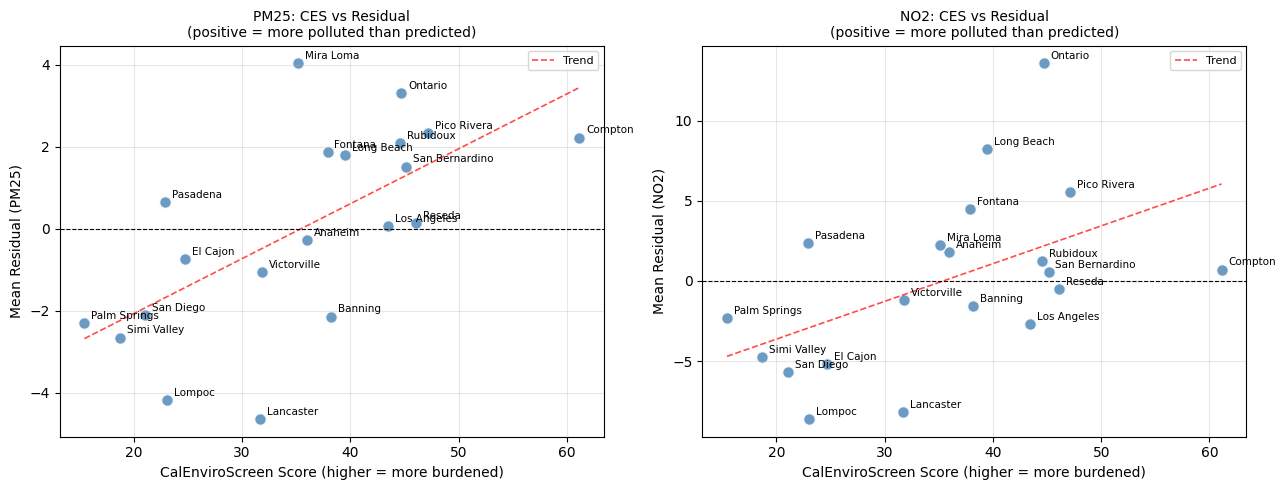

Saved ces_vs_residuals.png


In [224]:
import statsmodels.formula.api as smf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, outcome in zip(axes, OUTCOMES):
    # 1. Prepare the data first so we can fit a model on it
    # We still drop NAs for CES_score so we are looking at the exact same cities/years
    data = panel.dropna(subset=[outcome,'income_10k','ZEV_rate_lag','CES_score']).copy()

    # 2. Fit a model WITHOUT CES_score
    # NOTE: If you used year dummies in Model 3, make sure to add them to this formula too!
    # e.g., f"{outcome} ~ income_10k + ZEV_rate_lag + year_2019 + year_2020 ..."
    formula_no_ces = f"{outcome} ~ income_10k + log_total_vehicles + ZEV_rate_lag_resid"
    m_no_ces = smf.ols(formula_no_ces, data=data).fit(cov_type='cluster', cov_kwds={'groups': data['City']})

    # 3. Get residuals from this restricted model
    data['residual'] = m_no_ces.resid.values

    # --- Everything below remains exactly the same as your original code ---
    city_s = data.groupby('City').agg(
        CES_score=('CES_score','first'),
        mean_resid=('residual','mean')).reset_index()

    ax.scatter(city_s['CES_score'], city_s['mean_resid'],
               s=70, alpha=0.8, color='steelblue', edgecolors='white')
    for _, row in city_s.iterrows():
        ax.annotate(row['City'], (row['CES_score'], row['mean_resid']),
                    textcoords='offset points', xytext=(5,3), fontsize=7.5)

    if len(city_s) > 2:
        z  = np.polyfit(city_s['CES_score'], city_s['mean_resid'], 1)
        xl = np.linspace(city_s['CES_score'].min(), city_s['CES_score'].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), 'r--', linewidth=1.2, alpha=0.7, label='Trend')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('CalEnviroScreen Score (higher = more burdened)', fontsize=10)
    ax.set_ylabel(f'Mean Residual ({outcome})', fontsize=10)
    ax.set_title(f'{outcome}: CES vs Residual\n(positive = more polluted than predicted)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_p, 'ces_vs_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved ces_vs_residuals.png')